# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Pranav Sathyababu"
student_id = "25588726"
group_id = "24"

In [5]:
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple nba-draft-predictor==0.2.5

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
business_use_case_description = """
This project predicts the likelihood that a college or international basketball player will be drafted into the NBA based on performance, efficiency, and contextual attributes. The goal is to prioritize scouting resources, surface undervalued prospects earlier, and support data-driven draft decisions. By producing a ranked list with probabilities, the model helps front-office and scouting teams focus film study and workouts on the highest-upside players while quantifying risk.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
business_objectives = """
Accurate results will provide NBA teams with a reliable, data-driven tool to prioritize scouting
resources, identify undervalued prospects, and reduce uncertainty in draft decisions. This could
lead to better talent acquisition, stronger team performance, and long-term competitive advantage.
On the other hand, incorrect or misleading results could waste scouting resources, cause teams to
overlook high-potential players, or invest in players with low actual value. Therefore, accuracy is
critical, as the stakes of draft decisions involve multimillion-dollar contracts and the future
trajectory of a franchise.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
stakeholders_expectations_explanations = """
The results of this project will be used by NBA front-office executives, coaches, and scouting
departments to guide draft decision-making. The primary users of the predictions are scouts and
analysts who can combine model outputs with traditional evaluation methods to create a more
balanced and objective player assessment. Accurate predictions can also impact agents and players,
as strong draft likelihood scores may influence contract negotiations or player development focus.
Ultimately, team ownership and fans are indirectly impacted, since draft outcomes shape the long-term
success of a franchise. The model is therefore expected to be a complementary decision-support tool
that provides probabilistic insights rather than replacing human expertise.
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [15]:
X_train = pd.read_csv("../../data/processed/X_train.csv")
y_train = pd.read_csv("../../data/processed/y_train.csv")
X_val   = pd.read_csv("../../data/processed/X_val.csv")
y_val   = pd.read_csv("../../data/processed/y_val.csv")
X_test  = pd.read_csv("../../data/processed/X_test.csv")


train_df = pd.read_csv("../../data/raw/train.csv")
test_df  = pd.read_csv("../../data/raw/test.csv")

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [16]:
# <Student to fill this section>
performance_metrics_explanations = """
Since this is a binary classification problem (drafted vs not drafted) and the dataset is highly imbalanced (very few players are drafted compared to not drafted), we need performance metrics that go beyond accuracy.
AUROC (Area Under the ROC Curve): Best metric here, because it measures how well the model distinguishes between classes regardless of threshold. It is insensitive to class imbalance and widely used in imbalanced problems.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model - Random Forest Classifier

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
import numpy as np
import pandas as pd

In [19]:
algorithm_selection_explanations = """
Random Forest is a good fit for this project because it is well-suited for tabular data with 
mixed feature types and can naturally capture non-linear relationships and feature interactions. 
By combining multiple decision trees through bagging, it reduces variance and the risk of 
overfitting while still maintaining strong predictive performance. It also provides feature 
importance scores, which are valuable for interpreting which player attributes have the 
greatest influence on draft outcomes. Furthermore, Random Forest is robust to noise, handles 
missing values reasonably well, and scales efficiently, making it a reliable baseline and 
complementary model alongside gradient boosting methods like LightGBM and XGBoost.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Base model
rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)

# Param distributions
param_distributions = {
    "n_estimators": randint(200, 1200),
    "max_depth": randint(5, 40),                 # try bounded depths
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.8],
    "max_samples": uniform(0.6, 0.4)             # subsample rows (bootstrap sample size)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,                     # increase if you want a deeper search
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    refit=True                     # refit on full training set using best params
)

In [22]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Explain why you are tuning these hyperparameters
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [24]:
#Best params: {'max_depth': 28, 'max_features': 'log2', 'max_samples': np.float64(0.8460028906796679), 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 838}

In [25]:
# Fit search
search.fit(X_train, y_train)

# Best model
rf_best = search.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits


### J.4 Model Technical Performance

> Provide some explanations on model performance


Train AUROC: 0.9988545749155897
Valid AUROC: 0.9890150687923127

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2410
         1.0       0.44      0.74      0.55        19

    accuracy                           0.99      2429
   macro avg       0.72      0.86      0.77      2429
weighted avg       0.99      0.99      0.99      2429


Validation Confusion Matrix:
[[2392   18]
 [   5   14]]


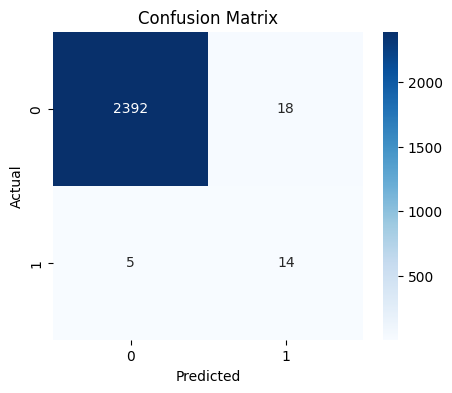

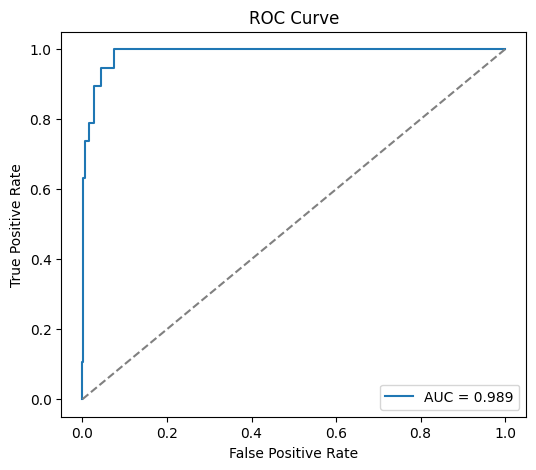

In [26]:
from nba_draft_predictor import evaluate_model, plot_confusion_matrix, plot_roc_curve

# Text-based evaluation
evaluate_model(rf_best, X_train, y_train, X_val, y_val)

# Confusion Matrix
y_val_pred = rf_best.predict(X_val)
plot_confusion_matrix(y_val, y_val_pred, labels=[0, 1])

# ROC Curve
y_val_proba = rf_best.predict_proba(X_val)[:, 1]
plot_roc_curve(y_val, y_val_proba)


In [27]:
X_train.columns

Index(['porpag', 'dporpag', 'bpm', 'gbpm', 'ogbpm', 'adjoe', 'twoPM', 'twoPA',
       'FTA', 'pts', 'stops', 'dreb', 'conf', 'ht', 'fta_per_pt',
       'scoring_eff', 'dreb_share', 'impact_index', 'pts_per_inch'],
      dtype='object')

In [28]:
from nba_draft_predictor import  make_submission_xlsx

submission = make_submission_xlsx(rf_best, X_test, test_df, "submission.xlsx")
submission.head()

submission.xlsx created


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.00000
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.00000
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.00925
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.00000
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.00000


In [29]:
model_performance_explanations = """
The Random Forest model achieved very strong results, with a validation AUROC of 0.989, indicating 
excellent ability to distinguish between drafted and non-drafted players. Performance on the majority 
class (not drafted) is nearly perfect, with precision and recall close to 1.0. For the minority drafted 
class, the model reached a recall of 0.74, meaning most drafted players were correctly identified, and 
a precision of 0.44, showing that some non-drafted players were incorrectly flagged as drafted. The 
confusion matrix confirms that only 5 drafted players were missed (false negatives), while 18 
non-drafted players were misclassified (false positives). Given the business context, this is a 
favorable trade-off, as it is more valuable to over-identify potential prospects than to miss 
high-value players. Overall, the model demonstrates strong generalization, outperforming baseline 
expectations, and provides actionable predictions for scouting prioritization.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [31]:
business_impacts_explanations = """
The Random Forest model provides strong predictive value, with a validation AUROC of 0.989, giving 
NBA teams confidence in using the predictions to prioritize scouting resources. The model almost 
perfectly identifies non-drafted players, minimizing wasted attention on low-probability prospects. 
For drafted players, recall of 0.74 ensures that most true prospects are flagged, reducing the risk 
of overlooking valuable talent. However, the lower precision of 0.44 means that some non-drafted 
players are incorrectly flagged as potential draftees, which may increase scouting workload. While 
this inefficiency carries moderate cost, its impact is less severe than false negatives, where a 
true drafted player is missed entirely. Missing drafted players could mean losing access to high-value 
talent and long-term competitive advantage. Therefore, even with false positives, the model supports 
the business objective by ensuring that promising prospects are rarely overlooked, aligning with the 
priority of maximizing draft success.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [33]:
# <Student to fill this section>
experiment_outcome = 'Hypothesis Partially Confirmed' 

In [34]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [35]:
experiment_results_explanations = """
The Random Forest model performed strongly (AUROC 0.989) and improved recall for drafted players 
(0.74), but precision remains low (0.44), meaning many false positives. This confirms the approach 
is promising but only partially meets the business objective. Next steps include threshold tuning, 
class imbalance methods (e.g., SMOTE, cost-sensitive learning), and feature engineering to improve 
precision while maintaining recall. Experiment 2 (Random Forest) improved AUROC and recall for drafted players, showing that ensemble 
trees are effective. However, precision remained low. The next step is to test LightGBM, a gradient 
boosting method that can better optimize class imbalance and often achieves higher precision with 
careful tuning. 
"""


In [36]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)